In [1]:
# ==============================================================================
# 1. IMPORTS & SETUP
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

# Setting a random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# ==============================================================================
# 2. DATA LOADING & PREPROCESSING
# ==============================================================================
print("--- ⚙️ INITIALIZING COMPUTER VISION PIPELINE ---")

# Loading the Fashion MNIST dataset directly from Keras API
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Defining the class names mapping for visualization purposes
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Normalization (CRITICAL FOR NEURAL NETWORKS):
# Image pixels are 8-bit integers (0 to 255). We normalize them to floats (0.0 to 1.0)
# to ensure faster and more stable convergence during gradient descent.
train_images = train_images / 255.0
test_images = test_images / 255.0

print(f"✅ Data Pipeline Ready!")
print(f"   Training images: {train_images.shape[0]} (Shape: {train_images.shape[1]}x{train_images.shape[2]})")
print(f"   Testing images:  {test_images.shape[0]}")

--- ⚙️ INITIALIZING COMPUTER VISION PIPELINE ---
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Data Pipeline Ready!
   Training images: 60000 (Shape: 28x28)
   Testing images:  10000


In [2]:
# ==============================================================================
# 3. NEURAL NETWORK ARCHITECTURE
# ==============================================================================
print("\n--- 🧠 BUILDING THE COMPUTER VISION MODEL ---")

# Sequential model definition
model = keras.Sequential([
    # Flattening Layer: Converts the 2D 28x28 image matrix into a 1D array of 784 pixels.
    # This spatial transformation is essential before feeding data into Dense layers,
    # mimicking how memory buffers serialize 2D data in hardware.
    keras.layers.Flatten(input_shape=(28, 28), name='Flatten_Input'),

    # Hidden Layer: 128 neurons using ReLU activation for non-linear feature extraction.
    # ReLU is computationally efficient for potential future edge-deployment.
    keras.layers.Dense(128, activation='relu', name='Dense_Hidden_1'),

    # Output Layer: 10 neurons corresponding to the 10 distinct clothing classes.
    # Softmax activation outputs a probability distribution across all classes.
    keras.layers.Dense(10, activation='softmax', name='Output_Softmax')
])

# Compiling the model
# Sparse Categorical Crossentropy is highly efficient for mutually exclusive classes
# where labels are integers (0-9) rather than one-hot encoded vectors.
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# ==============================================================================
# 4. MODEL TRAINING
# ==============================================================================
print("\n--- 🚀 TRAINING THE NETWORK ---")

# Training the model on the training dataset
# Using validation_split to monitor overfitting during training.
history = model.fit(train_images, train_labels,
                    epochs=10,
                    validation_split=0.2,
                    verbose=1)

print("✅ Training Complete!")


--- 🧠 BUILDING THE COMPUTER VISION MODEL ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Flatten_Input (Flatten)         │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_Hidden_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Softmax (Dense)          │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)


--- 🚀 TRAINING THE NETWORK ---
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8179 - loss: 0.5199 - val_accuracy: 0.8471 - val_loss: 0.4342
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8616 - loss: 0.3900 - val_accuracy: 0.8598 - val_loss: 0.3890
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8743 - loss: 0.3477 - val_accuracy: 0.8729 - val_loss: 0.3591
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8825 - loss: 0.3214 - val_accuracy: 0.8732 - val_loss: 0.3476
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8896 - loss: 0.3002 - val_accuracy: 0.8777 - val_loss: 0.3437
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8957 - loss: 0.2835 - val_accuracy: 0.8802 - val_loss: 0.3392
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9010 - loss: 0.2680 - val_accuracy: 0.8829 - val_loss: 0.3360
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - ac


--- 📊 EVALUATING MODEL PERFORMANCE ---
🎯 Final Test Accuracy: 87.77%



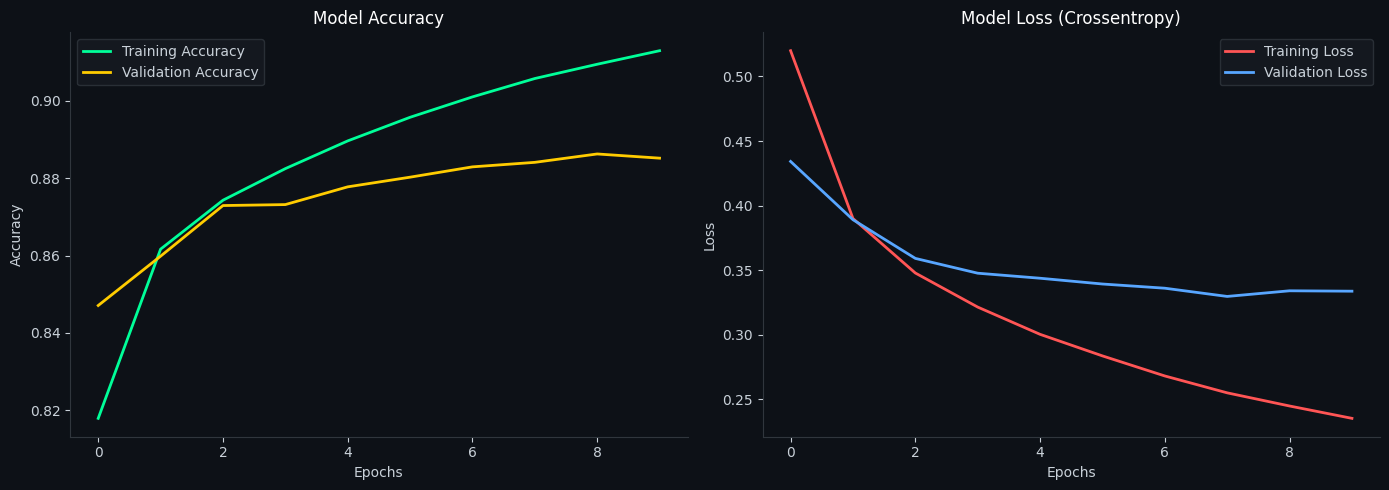

In [3]:
# ==============================================================================
# 5. MODEL EVALUATION & LEARNING CURVES
# ==============================================================================
print("\n--- 📊 EVALUATING MODEL PERFORMANCE ---")

# Evaluating the model on unseen test data to guarantee no overfitting
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print(f"🎯 Final Test Accuracy: {test_acc * 100:.2f}%\n")

# Plotting Training and Validation Accuracy/Loss with a professional Dark Theme
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')

# Applying style to both subplots
for ax in axes:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='#c9d1d9')
    ax.xaxis.label.set_color('#c9d1d9')
    ax.yaxis.label.set_color('#c9d1d9')
    ax.title.set_color('#ffffff')
    ax.title.set_fontsize(14)
    ax.spines['bottom'].set_color('#30363d')
    ax.spines['left'].set_color('#30363d')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 1. Accuracy Plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy', color='#00ff99', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='#ffcc00', linewidth=2)
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')

# 2. Loss Plot
axes[1].plot(history.history['loss'], label='Training Loss', color='#ff5555', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='#58a6ff', linewidth=2)
axes[1].set_title('Model Loss (Crossentropy)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')

plt.tight_layout()
plt.show()


--- 👁️ VISUALIZING PREDICTIONS & CONFUSION MATRIX ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


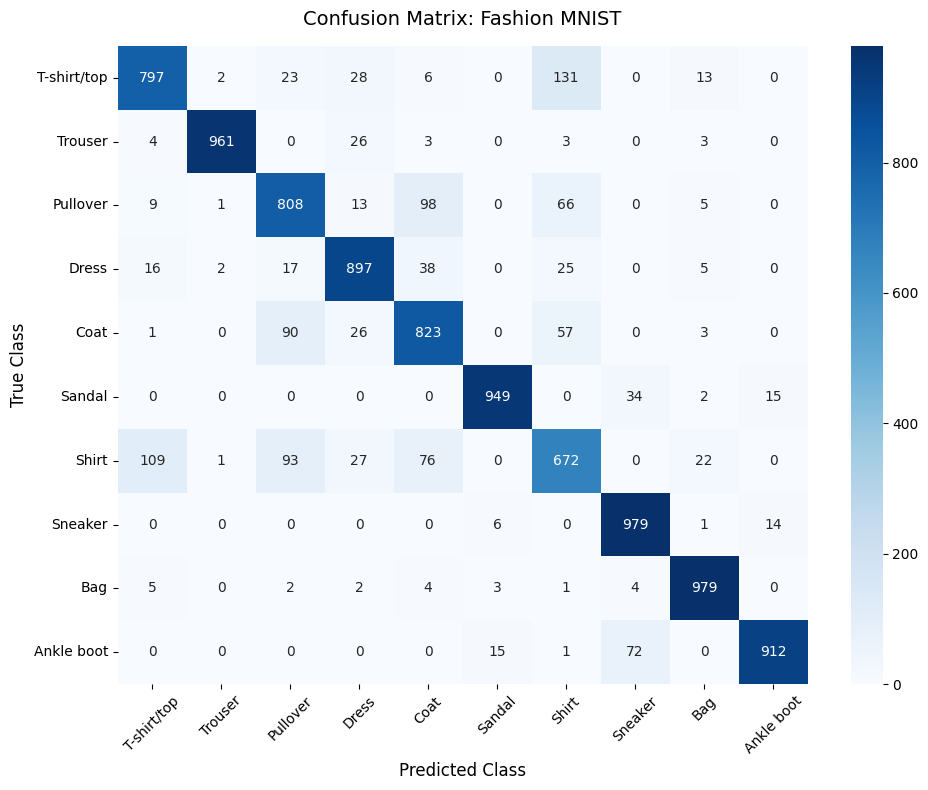


--- 👕 EVALUATING REAL-WORLD INFERENCE ---


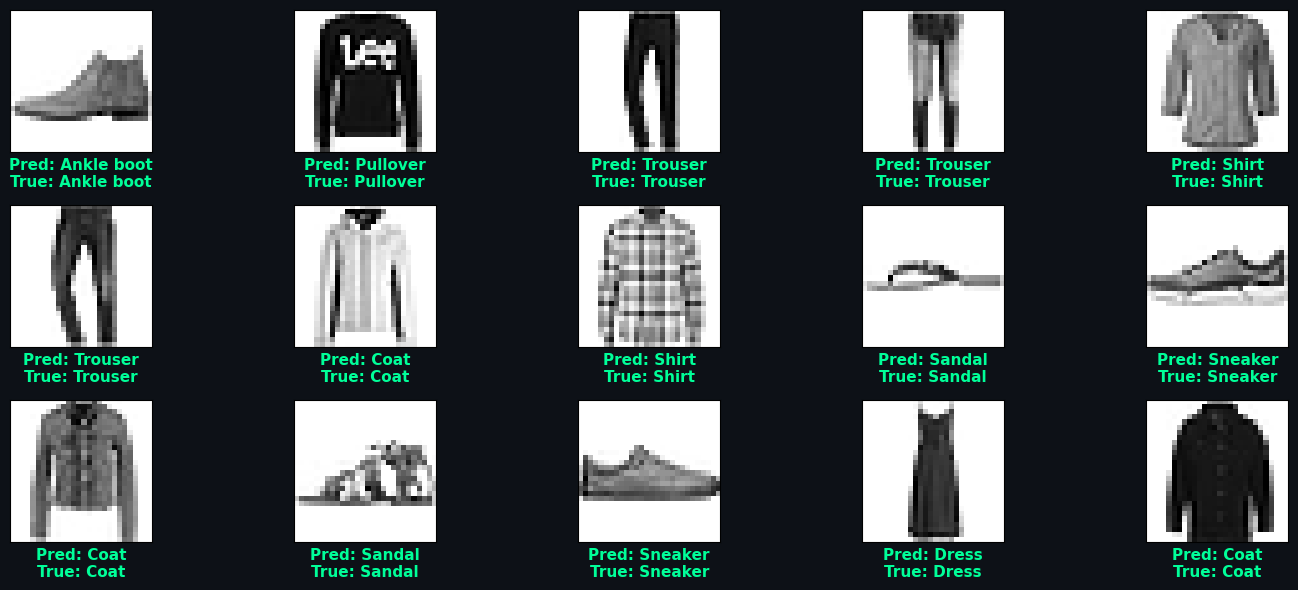

In [4]:
# ==============================================================================
# 6. CONFUSION MATRIX & VISUAL PREDICTIONS
# ==============================================================================
from sklearn.metrics import confusion_matrix
print("\n--- 👁️ VISUALIZING PREDICTIONS & CONFUSION MATRIX ---")

# Generating predictions for the test dataset
predictions = model.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)

# 1. Plotting the Confusion Matrix
cm = confusion_matrix(test_labels, predicted_classes)

plt.figure(figsize=(10, 8))
# Using a 'Blues' heatmap for clean, professional data visualization
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Fashion MNIST', fontsize=14, pad=15)
plt.ylabel('True Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ==============================================================================
# 7. MODEL IN ACTION: REAL VS PREDICTED
# ==============================================================================
print("\n--- 👕 EVALUATING REAL-WORLD INFERENCE ---")

# Setting up a dark-themed plot for image evaluation
fig = plt.figure(figsize=(15, 6))
fig.patch.set_facecolor('#0d1117')

# Displaying the first 15 images from the test set
for i in range(15):
    ax = plt.subplot(3, 5, i + 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)

    # Inverting the binary color map to look better on dark backgrounds
    plt.imshow(test_images[i], cmap=plt.cm.binary)

    true_label = test_labels[i]
    predicted_label = predicted_classes[i]

    # Color logic: Green for correct predictions, Red for mistakes
    color = '#00ff99' if true_label == predicted_label else '#ff5555'

    plt.xlabel(f"Pred: {class_names[predicted_label]}\nTrue: {class_names[true_label]}",
               color=color, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()